# Graficas primitias con Shapely

In [1]:
from shapely.geometry import Point

In [2]:
punto1 = Point(2.2, 4.2)
punto2 = Point(7, -25)
punto3 = Point(9.26, -2.456)
punto_3d = Point(9.26, -2.456, 0.57)

In [3]:
print(punto1)
print(punto2)
print(punto3)
print(punto_3d)

POINT (2.2 4.2)
POINT (7 -25)
POINT (9.26 -2.456)
POINT Z (9.26 -2.456 0.57)


### Atributos y funciones
* geom_type: indica el tipo de geometría.

* Coords: permite acceder a las coordenadas del punto a través de un objeto CoordinateSequence.

* distance(): calcula la distancia entre dos puntos.

In [4]:
punto1.geom_type

'Point'

In [5]:
punto1.coords
list(punto1.coords)

[(2.2, 4.2)]

In [6]:
punto1.distance(punto2)

29.591890781090687

### Linea
#### LineString

In [7]:
from shapely.geometry import Point, LineString

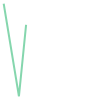

In [8]:
linea = LineString([punto1, punto2, punto3])
linea2 = LineString([(2.2, 4.2), (7, -25), (9.26,-2.456)])
linea

In [9]:
print(linea)
linea == linea2

LINESTRING (2.2 4.2, 7 -25, 9.26 -2.456)


True

### Atributos de LineString
* Coords -> Coordenadas de la linea
* xy -> obtiene por separado coordenadas de x o de y
* lenght -> longitud de la linea
* centroid -> devuelve el punto que representa el centroide de la linea

In [10]:
print(linea.coords)
list(linea.coords)

[(2.2, 4.2), (7.0, -25.0), (9.26, -2.456)]

In [11]:
xcoords = list(linea.xy[0])
print(xcoords)
ycoords = list(linea.xy[1])
print(ycoords)

[2.2, 7.0, 9.26]
[4.2, -25.0, -2.456]


In [12]:
longitud = linea.length
print(longitud)

52.24888828738


In [13]:
print(linea.centroid)

POINT (6.130734984394282 -11.843140517865203)


# Poligonos
### Clase Polygon

In [14]:
from shapely.geometry import Point, LineString, Polygon


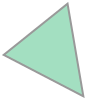

In [15]:
poligono = Polygon([(2.2, 4.2), (7.2, -25.1), (-18, -12)])
poligono

### Poligono con hueco

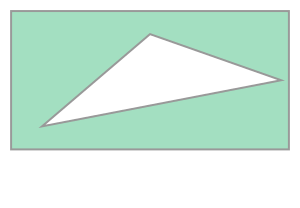

In [16]:
contorno = [(-180, 90), (-180, -90), (180, -90), (180, 90)]
hueco = [[(0, 60), (-140, -60), (170, 0)]]
poligono_con_hueco = Polygon(shell=contorno, holes=hueco)
poligono_con_hueco

### Atributos de Polygon
* centroid -> representa el centroide del poligono con un Point
* area -> Regresa el area del poligono 
* bounds -> Regresa el polígono rectangular mínimo que encierra al polígono.
* exterior -> Regresa un objeto LinearRing, que define el borde exterior del polígono. Un LinearRing es similar a una LineString, pero se diferencia en que es cerrada, lo que significa que el primer punto coincide con el último.
* lenght -> Perimetro del poligono

In [17]:
print("El centroide delpolígono es: ", poligono_con_hueco.centroid)
print("El área del polígono es: ", poligono_con_hueco.area)
print("El rectángulo mínimo que contiene al polígono es: ", poligono_con_hueco.bounds)
print("El exterior del polígono es: ", poligono_con_hueco.exterior)
print("El prímetro del polígono es: ", poligono_con_hueco.exterior. length)

El centroide delpolígono es:  POINT (-2.857142857142857 0)
El área del polígono es:  50400.0
El rectángulo mínimo que contiene al polígono es:  (-180.0, -90.0, 180.0, 90.0)
El exterior del polígono es:  LINEARRING (-180 90, -180 -90, 180 -90, 180 90, -180 90)
El prímetro del polígono es:  1080.0



## 2. INTEGRACIÓN EN GEOPANDAS (GEODATAFRAME)


### Creación de un diccionario con atributos e información espacial


--- GeoDataFrame Creado ---
            Nombre      Tipo_Entidad  \
0      Ubicación A  Punto de Interés   
1   Ruta Principal              Ruta   
2  Zona Delimitada      Área Privada   

                                            geometry  
0                           POINT (-99.1332 19.4326)  
1  LINESTRING (-99.13 19.43, -99.14 19.44, -99.15...  
2  POLYGON ((-99.16 19.41, -99.17 19.41, -99.17 1...  


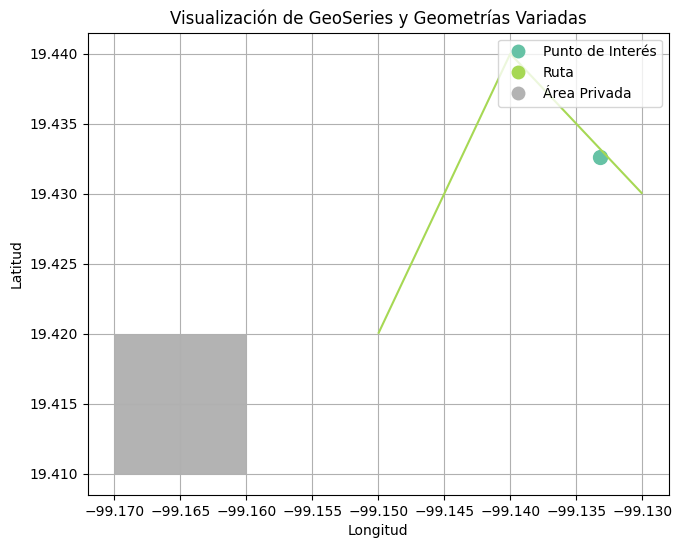

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiPolygon, Point, Polygon

datos_espaciales = {
    'Nombre': ['Ubicación A', 'Ruta Principal', 'Zona Delimitada'],
    'Tipo_Entidad': ['Punto de Interés', 'Ruta', 'Área Privada'],
    'geometry': [
        Point(-99.1332, 19.4326),  # Ejemplo: CDMX
        LineString([(-99.13, 19.43), (-99.14, 19.44), (-99.15, 19.42)]),
        Polygon([
            (-99.16, 19.41),
            (-99.17, 19.41),
            (-99.17, 19.42),
            (-99.16, 19.42),
        ]),
    ],
}

# Crear el GeoDataFrame
gdf = gpd.GeoDataFrame(datos_espaciales, crs='EPSG:4326')

print('\n--- GeoDataFrame Creado ---')
print(gdf[['Nombre', 'Tipo_Entidad', 'geometry']])

# Visualización rápida
fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(ax=ax, column='Tipo_Entidad', legend=True, cmap='Set2', markersize=100)
plt.title('Visualización de GeoSeries y Geometrías Variadas')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()